<h1 style = 
"color:blue ;
text-align:center ;
font-size:75px ;
font-style:italic ;
font-family:sherif ;
font-weight:bold ">
Loan Risk Prediction </h1>

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 1 : Import Required Library & Dataset , Apply Data Preprocessing Steps </h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use('ggplot')

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv('loan_risk_prediction_dataset.csv')
print(JP.head(20))

print("\n")
print("Identify Missing Values")
print("\n")
print(JP.isna().sum())

print("\n")
print("Duplicates === ",JP.duplicated().sum())
print("\n")
print("Number OF Rows & Columns == ",JP.shape)

JP.drop(columns=['Age'],inplace=True)

print("\n")
print("Identify Negative Values")
print("\n")
print(JP['LoanAmount'].sort_values().head(10))

JP=JP.query(" LoanAmount > 0 ")

print("\n")
print("After Remove Negative Values")
print("\n")
print(JP['LoanAmount'].sort_values().head(10))

print("\n")
print(JP.info())


    Age   Income  LoanAmount  CreditScore  YearsExperience  Gender    Education           City EmploymentType Loan Status
0    56  48353.0       31258        675.0               20  Female  High School        Houston     Unemployed    Approved
1    69  57462.0       23262        586.0                6    Male  High School  San Francisco  Self-Employed    Approved
2    46  44219.0       26530        781.0               26    Male          PhD        Houston  Self-Employed    Rejected
3    32  56307.0       11531        549.0               11    Male          NaN       New York     Unemployed    Approved
4    60  37034.0       27871        500.0               19  Female  High School        Chicago     Unemployed    Approved
5    25  47886.0       18106        835.0               13    Male      Masters       New York       Salaried    Rejected
6    38  54748.0       25374        760.0                9  Female  High School       New York  Self-Employed    Rejected
7    56      NaN        

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold">Step 2 : Feature Selection [ Split Data into X ( Features ) & Y ( Target ) ] </h1>

In [2]:
x=JP.drop(columns=('Loan Status'),axis=1)
y=JP['Loan Status']

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 3 : Data Cleaning [ Handling Missing Values ] </h1>

In [3]:
numeric_col = x.select_dtypes(include=['int64','float64']).columns
categorical_col = x.select_dtypes(include=['object']).columns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric = Pipeline([('imputer',SimpleImputer(strategy='median'))])
categorical = Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore'))])

preprocessing = ColumnTransformer([('Numeric',numeric,numeric_col),('Categorical',categorical,categorical_col)])

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 4 : Exploratory Data Analysis ( EDA ) </h1>

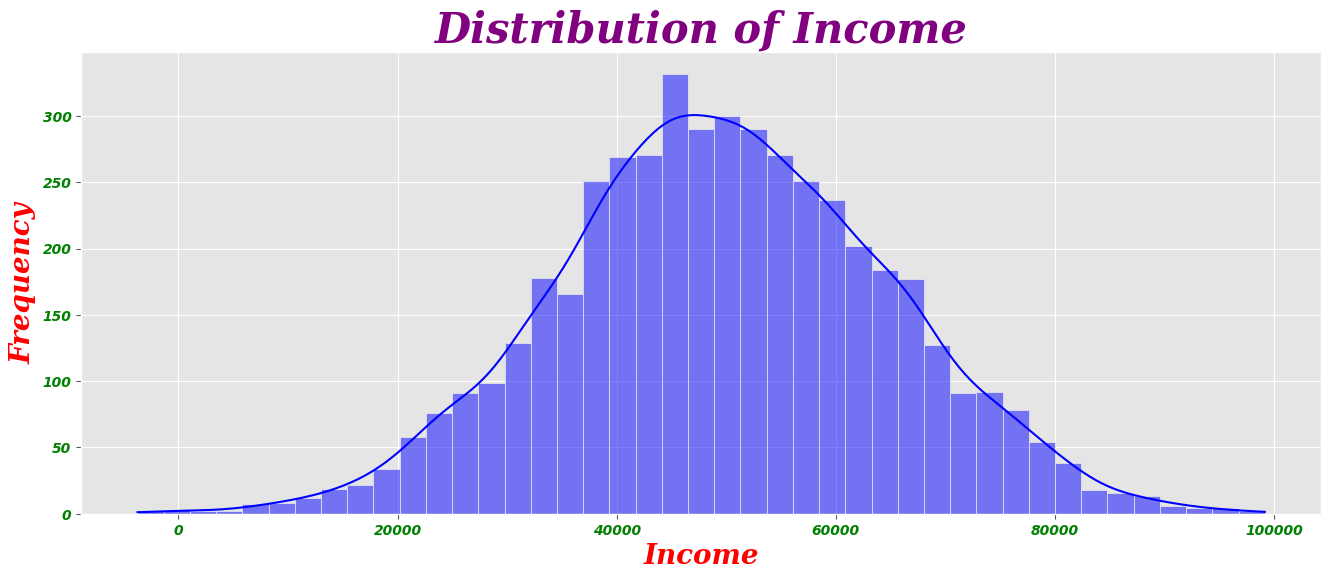

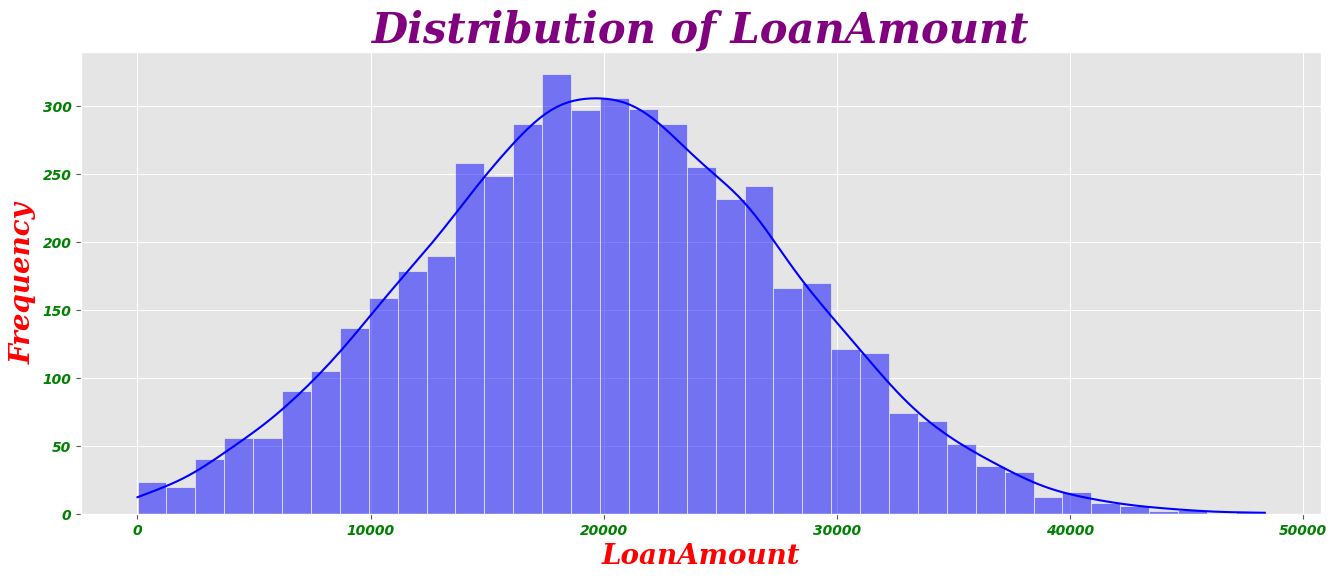

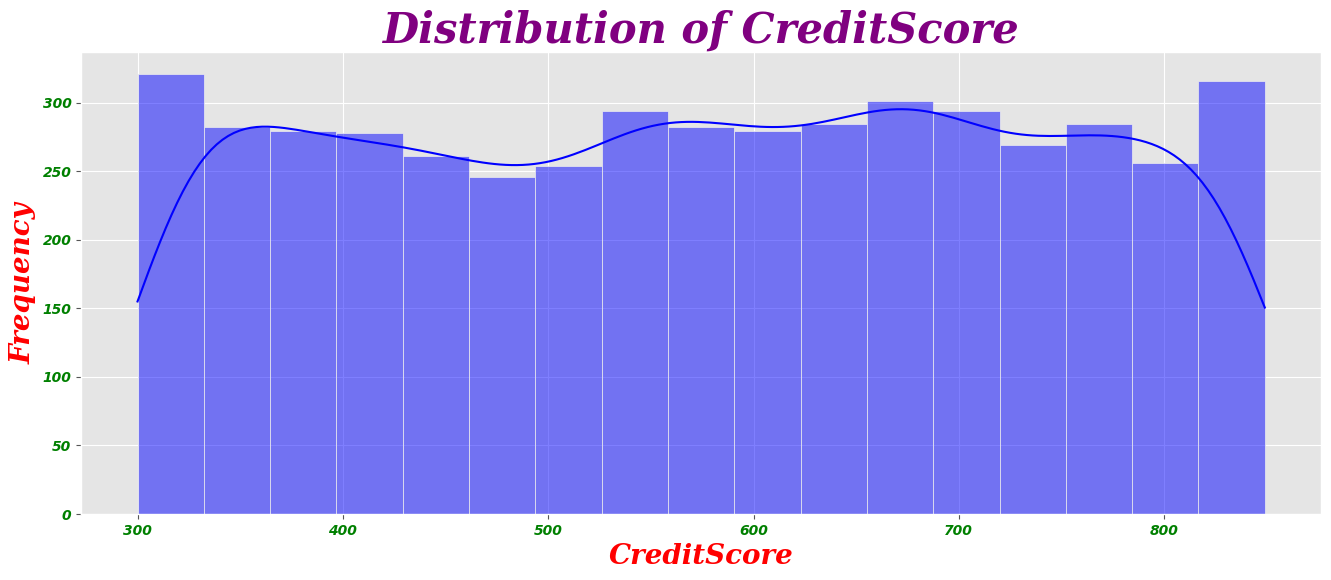

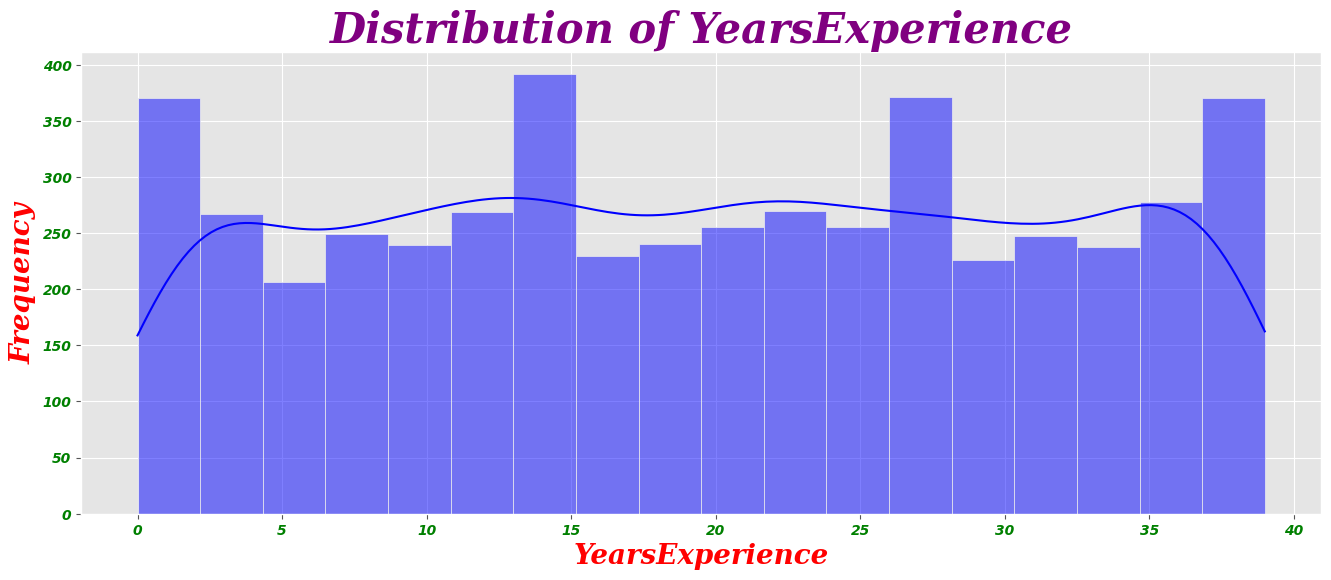

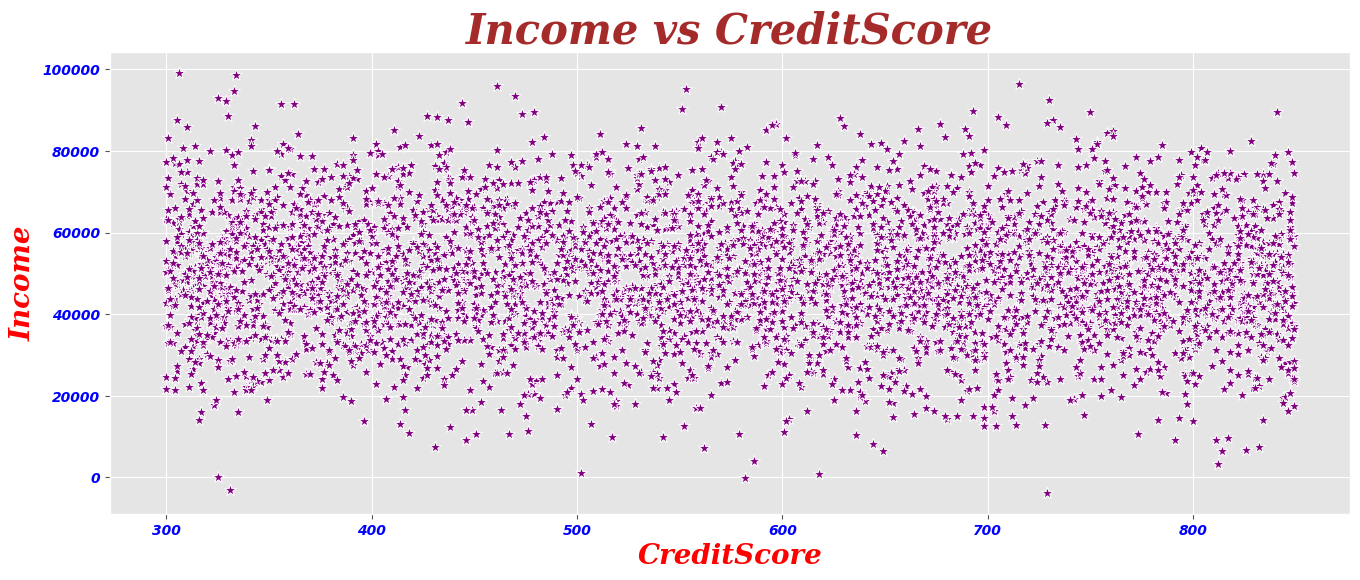

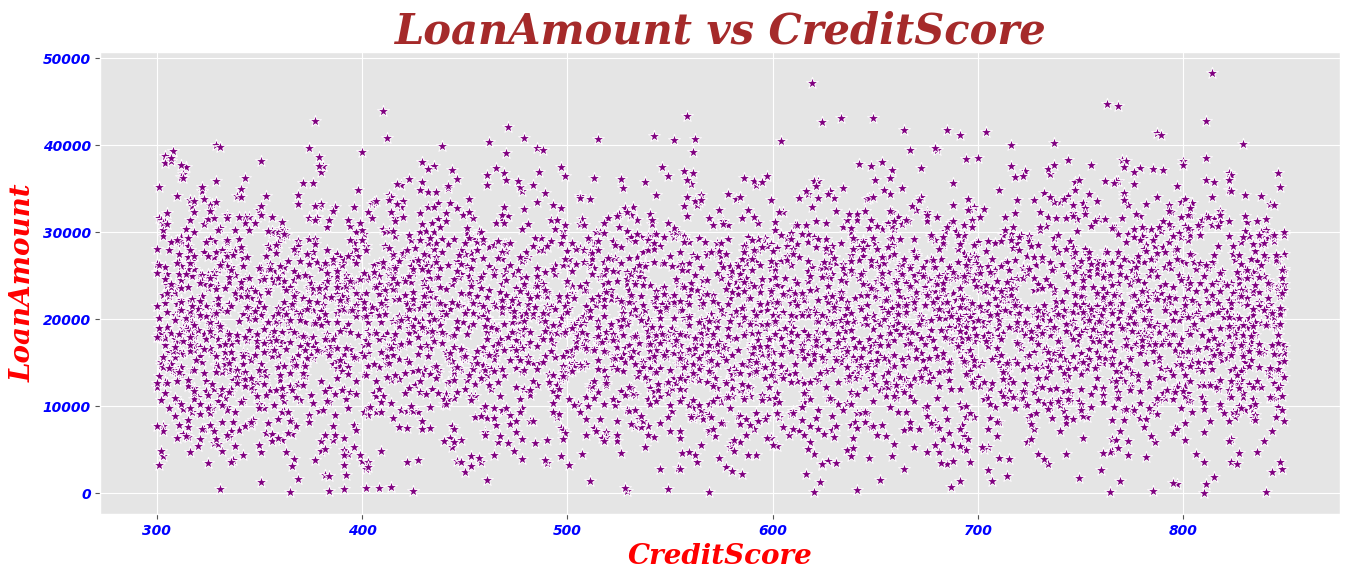

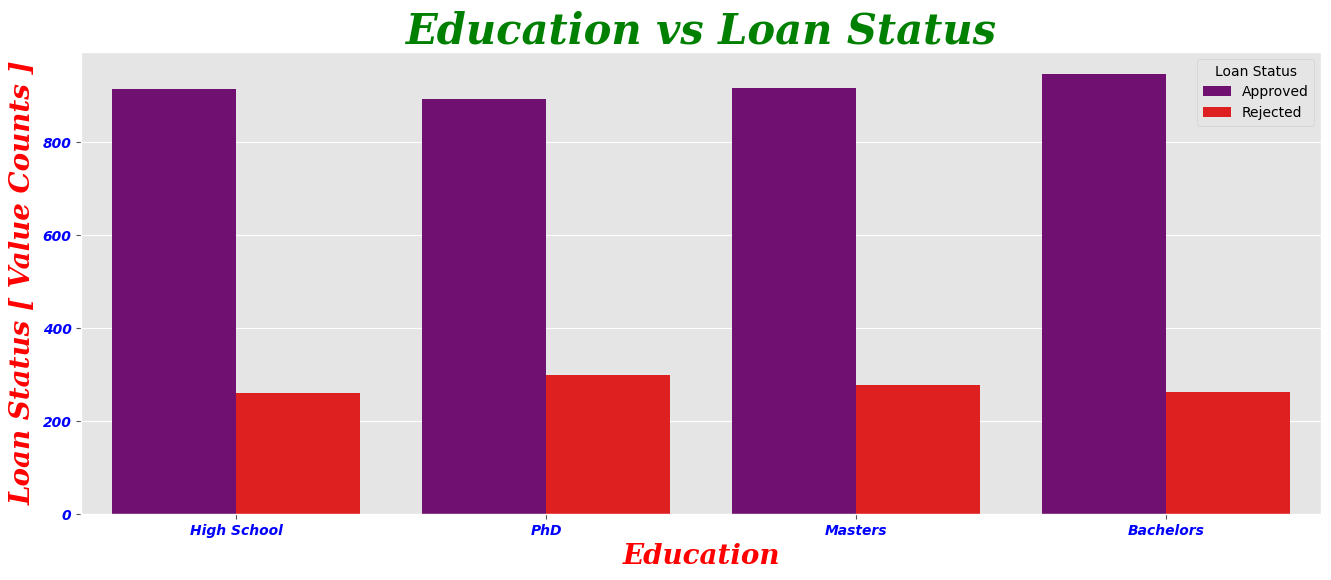

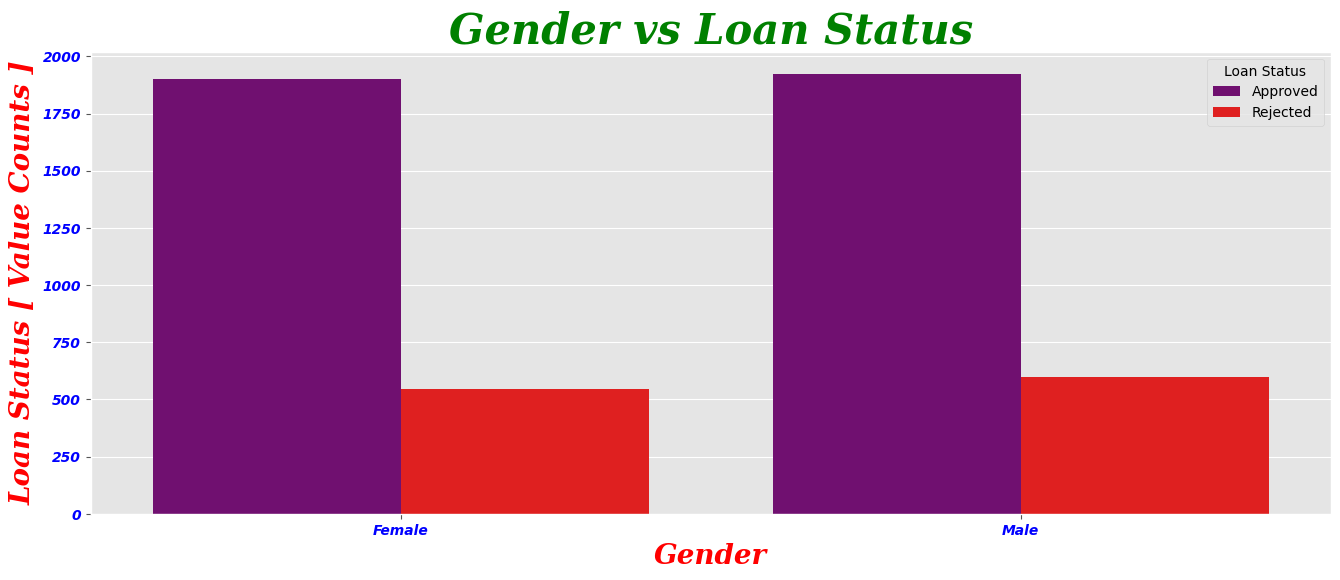

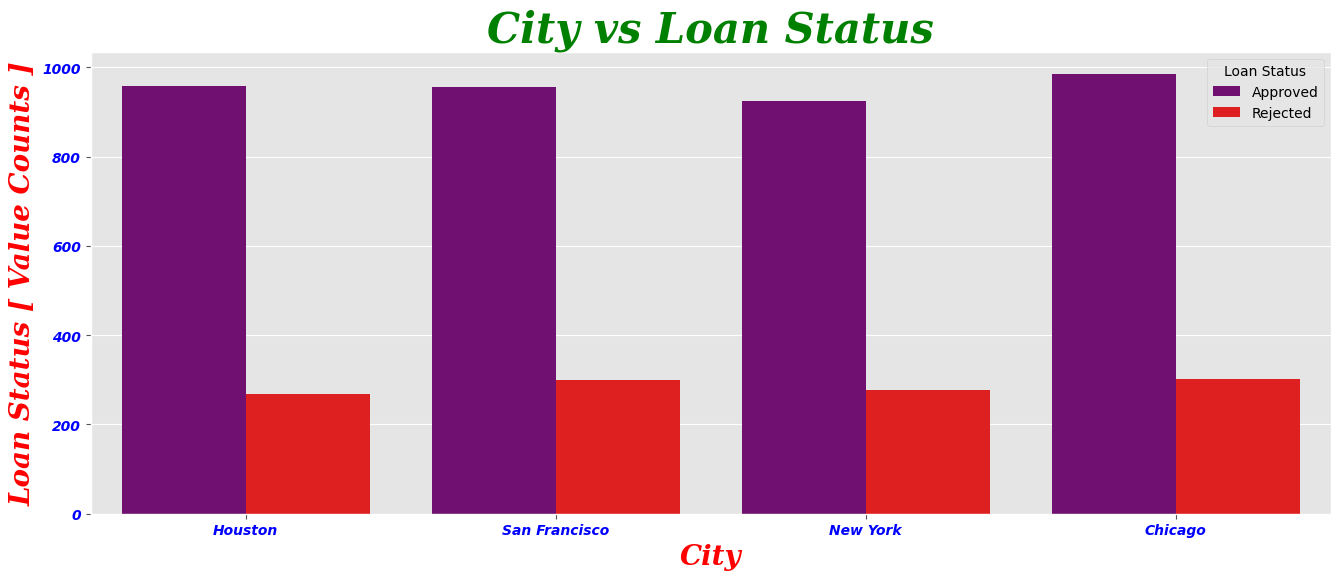

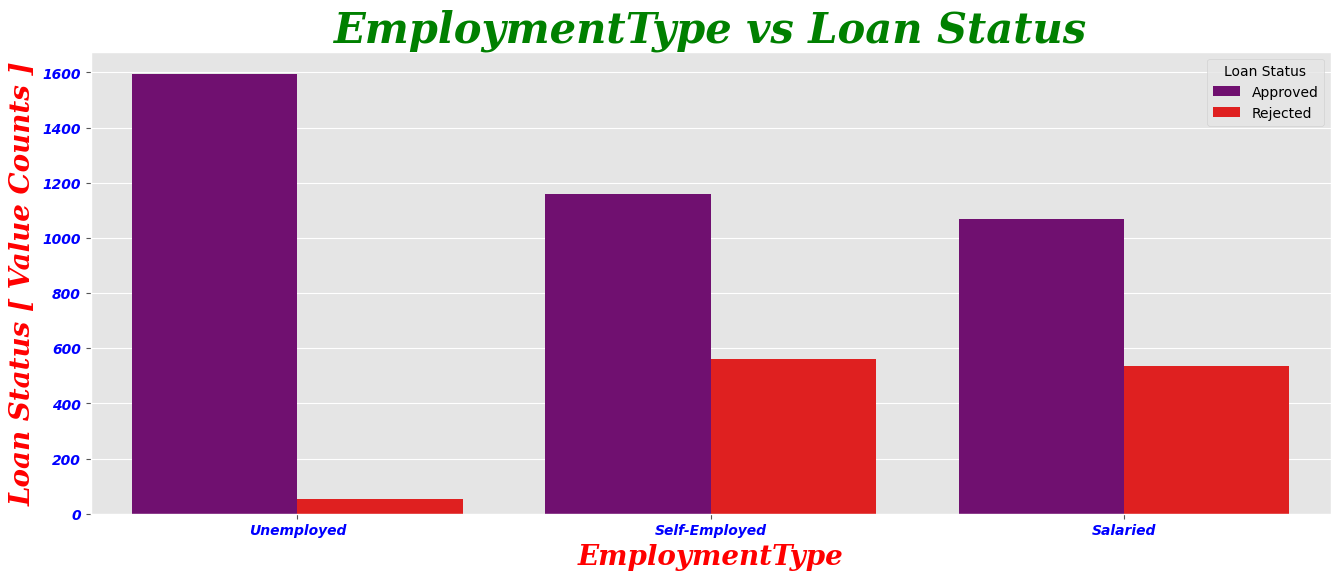

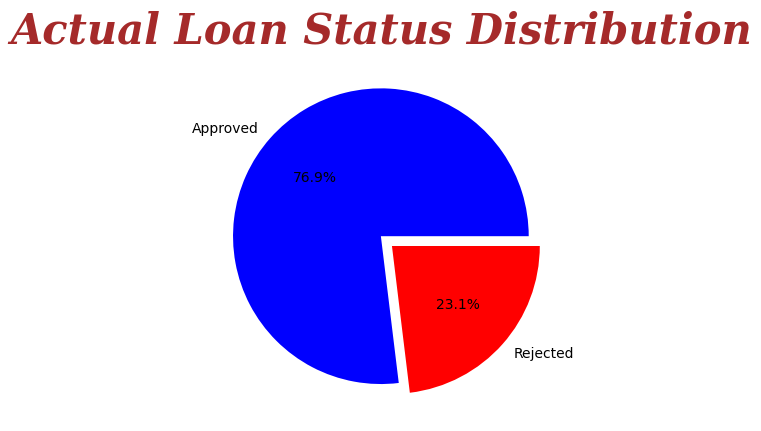

In [4]:
for col in numeric_col :
    plt.figure(figsize=(16,6))
    sns.histplot(data=JP,x=col,kde=True,color='blue')
    plt.title(f'Distribution of {col}',fontsize=30,fontweight='bold',color='purple',fontdict={'family':'serif'},fontstyle='italic')
    plt.xlabel(col,fontsize=20,fontweight='bold',color='red',fontdict={'family':'serif'},fontstyle='italic')
    plt.ylabel("Frequency",fontsize=20,fontweight='bold',color='red',fontdict={'family':'serif'},fontstyle='italic')
    plt.xticks(fontweight='bold',fontstyle='italic',fontsize=10,color='green')
    plt.yticks(fontweight='bold',fontstyle='italic',fontsize=10,color='green')
    plt.show()

scatter_plt = JP [['Income','LoanAmount']]

for col in scatter_plt :
    plt.figure(figsize=(16,6))
    sns.scatterplot(data=JP,x="CreditScore",y=col,marker="*",s=80,color='purple')
    plt.title(f'{col} vs CreditScore',fontsize=30,fontweight='bold',color='brown',fontdict={'family':'serif'},fontstyle='italic')
    plt.xlabel("CreditScore",fontsize=20,fontweight='bold',color='red',fontdict={'family':'serif'},fontstyle='italic')
    plt.ylabel(col,fontsize=20,fontweight='bold',color='red',fontdict={'family':'serif'},fontstyle='italic')
    plt.xticks(fontweight='bold',fontstyle='italic',fontsize=10,color='blue')
    plt.yticks(fontweight='bold',fontstyle='italic',fontsize=10,color='blue')
    plt.show()

count_plt = JP [["Education","Gender","City","EmploymentType"]]

for col in count_plt :
    plt.figure(figsize=(16,6))
    sns.countplot(data=JP,x=col,hue="Loan Status",palette={'Approved':'purple','Rejected':'red'})
    plt.title(f'{col} vs Loan Status',fontsize=30,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')
    plt.xlabel(col,fontsize=20,fontweight='bold',color='red',fontdict={'family':'serif'},fontstyle='italic')
    plt.ylabel("Loan Status [ Value Counts ]",fontsize=20,fontweight='bold',color='red',fontdict={'family':'serif'},fontstyle='italic')
    plt.xticks(fontweight='bold',fontstyle='italic',fontsize=10,color='blue')
    plt.yticks(fontweight='bold',fontstyle='italic',fontsize=10,color='blue')
    plt.show()

plt.pie(JP['Loan Status'].value_counts(),labels=JP['Loan Status'].value_counts().index,autopct='%1.1f%%',colors=['blue','red'],explode=[0,0.1])
plt.title("Actual Loan Status Distribution",fontsize=30,fontweight='bold',color='brown',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 5 : Train_Test_Split & Model Selection ( Multiple Models Trained ) </h1>

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=98)


from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(max_depth=5,criterion='gini',random_state=58)

DT_model = Pipeline([ ( 'Preprocessing',preprocessing ),( 'Model',dt ) ])

DT_model.fit(x_train,y_train)
Y_Pred=DT_model.predict(x_test)


from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=67)

rf_model = Pipeline ([ ( 'Preprocessing',preprocessing ),( 'Model',rf ) ])

rf_model.fit(x_train,y_train)
RFY_Pred=rf_model.predict(x_test)


from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)

lr_model = Pipeline ([ ( 'Preprocessing',preprocessing ),( 'Model',lr ) ])

lr_model.fit(x_train,y_train)
LRY_Pred=lr_model.predict(x_test)


from sklearn.svm import SVC

svm = SVC (kernel='rbf',C=1.0,gamma='scale',class_weight='balanced',random_state=34)

svm_model = Pipeline( [ ( 'Preprocessing',preprocessing ),( 'Model',svm ) ])

svm_model.fit(x_train,y_train)
svmY_Pred = svm_model.predict(x_test)

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Model Accuracy Comparision </h1>

In [6]:
from sklearn.metrics import accuracy_score

accuracy ={
    "Decision Tree":accuracy_score(y_test,Y_Pred),
    "Logistic Regression":accuracy_score(y_test,LRY_Pred),
    "Random Forest":accuracy_score(y_test,RFY_Pred),
    "SVM":accuracy_score(y_test,svmY_Pred),
}
print(accuracy)

{'Decision Tree': 0.9718592964824121, 'Logistic Regression': 0.8984924623115578, 'Random Forest': 0.9748743718592965, 'SVM': 0.4824120603015075}


<h1 style = "color:green;font-size:30px;font-style:italic;font-family:sherif;font-weight:bold;text-align:center"> Final Model Selected [ Decision Tree ] </h1>

<h1 style = "color:green;font-size:25px;font-style:italic;font-family:sherif;font-weight:bold"> Step 6 : Model Evalution </h1>

In [7]:
Train_Score=DT_model.score(x_train,y_train)
Test_Score=DT_model.score(x_test,y_test)

print("\n")
print("Train Score === ",Train_Score)
print("Test Score === ",Test_Score)

from sklearn.model_selection  import cross_val_score

score=cross_val_score(DT_model,x_train,y_train,cv=5,scoring='accuracy')
print("\n")
print("CVS OF Decision Tree Classifier ==== ",score)
print("Average CVS OF Decision Tree Classifier ==== ",score.mean())

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print("\n")
print("Accuracy Of Decision Tree Classifier : ")
print(accuracy_score(y_test,Y_Pred) * 100 , "%")

print("\n")
print("Confusion Matrics : ")
CM=confusion_matrix(y_test,Y_Pred)
print(CM)

print("\n")
print("Classification Report : ")
print(classification_report(y_test,Y_Pred))



Train Score ===  0.9705808398290169
Test Score ===  0.9718592964824121


CVS OF Decision Tree Classifier ====  [0.9660804  0.96356784 0.96226415 0.96981132 0.95849057]
Average CVS OF Decision Tree Classifier ====  0.9640428557883759


Accuracy Of Decision Tree Classifier : 
97.18592964824121 %


Confusion Matrics : 
[[769  10]
 [ 18 198]]


Classification Report : 
              precision    recall  f1-score   support

    Approved       0.98      0.99      0.98       779
    Rejected       0.95      0.92      0.93       216

    accuracy                           0.97       995
   macro avg       0.96      0.95      0.96       995
weighted avg       0.97      0.97      0.97       995



<h1 style = "color:green;font-size:25px;font-style:italic;font-family:serif;font-weight:bold">Step 7 : Final Prediction </h1>

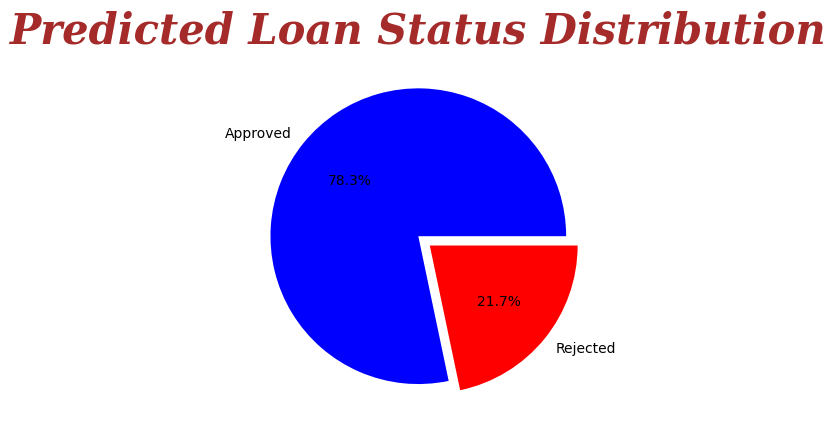

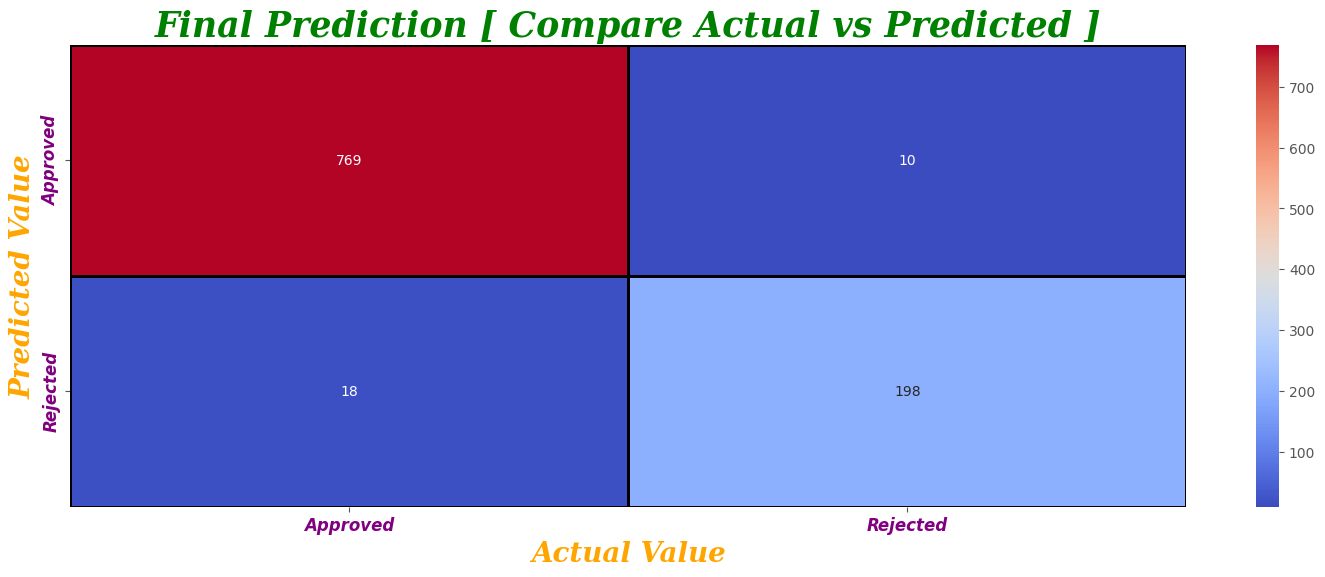

In [10]:
from sklearn.tree import plot_tree
# from sklearn.tree import export_text

Model = DT_model.named_steps['Model']
prep = DT_model.named_steps['Preprocessing']
feature = prep.get_feature_names_out()

# Tree_Rules=export_text(Model,feature_names=feature)
# print(Tree_Rules)

plt.figure(figsize=(100,75))
plot_tree(
    Model,
    feature_names=feature,
    class_names=["Approved","Rejected"],    
    filled=True,
    rounded=True,
    fontsize=25
)
plt.tight_layout()
plt.title("Decision Tree ",fontsize=150,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

plt.pie(y_test.value_counts(),labels=y_test.value_counts().index,autopct='%1.1f%%',colors=['blue','red'],explode=[0,0.1])
plt.title("Predicted Loan Status Distribution",fontsize=30,fontweight='bold',color='brown',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

plt.figure(figsize=(18,6))
sns.heatmap(CM,annot=True,fmt='d',cmap='coolwarm',xticklabels=["Approved","Rejected",],yticklabels=["Approved","Rejected"],linewidths=1,linecolor='black')
plt.title("Final Prediction [ Compare Actual vs Predicted ]",fontsize=25,fontweight='bold',color='Green',fontdict={'family':'serif'},fontstyle='italic')
plt.xlabel("Actual Value",fontsize=20,color='orange',fontweight='bold',fontdict={'family':'serif'},fontstyle='italic')
plt.ylabel("Predicted Value",fontsize=20,color='orange',fontweight='bold',fontdict={'family':'serif'},fontstyle='italic')
plt.xticks(color='purple',fontstyle='italic',fontsize=12,fontweight='bold')
plt.yticks(color='purple',fontstyle='italic',fontsize=12,fontweight='bold')
plt.show()